In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Opgave 9.1

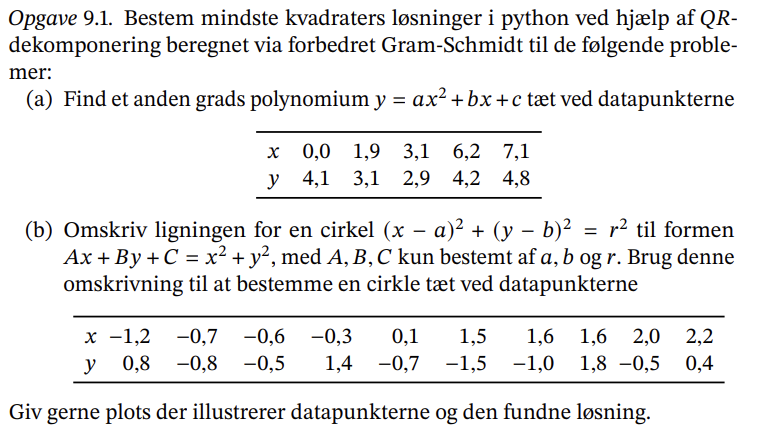

## (a) 

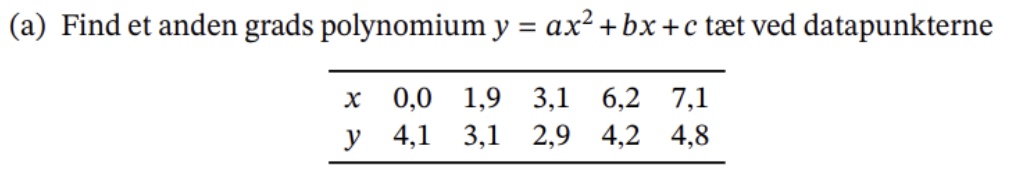

Vi skal bestemme mindste kvadraters løsning vha QR-dekomponering, dermed skal vi bruge følgende opskrift:

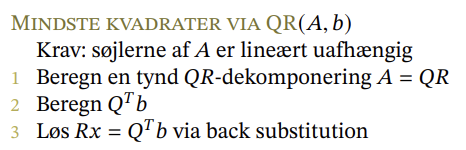

Jeg angiver først en vandemonder matrice som vores $A$ matrice:

In [3]:
xcord = np.array([0.0, 1.9, 3.1, 6.2, 7.1], dtype=float)
b = np.array([4.1, 3.1, 2.9, 4.2, 4.8], dtype=float)

A = np.vander(xcord, 3, increasing=False)
A

array([[ 0.  ,  0.  ,  1.  ],
       [ 3.61,  1.9 ,  1.  ],
       [ 9.61,  3.1 ,  1.  ],
       [38.44,  6.2 ,  1.  ],
       [50.41,  7.1 ,  1.  ]])

Jeg vil nu løse følgende ligning:

$$Ax = Pb$$
$$\Updownarrow$$
$$QRx = QQ^Tb$$
$$\Updownarrow$$
$$Rx = Q^Tb$$

Da $Q$ er ortogonal og har samme søjlerum som $A$, så må $QQ^T$ give os projektionsmatricen ned på dette søjlerum.

In [4]:
# Angivelse af forbedret gram-schmidt
def forbedret_gram_schmidt(a):
    _, k = a.shape
    q = np.copy(a)
    r = np.zeros((k, k))
    for i in range(k):
        r[i, i] = np.linalg.norm(q[:, i])
        q[:, i] /= r[i, i]
        r[[i], i+1:] = q[:, [i]].T @ q[:, i+1:]
        q[:, i+1:] -= q[:, [i]] @ r[[i], i+1:]
    return q, r

In [5]:
# 1. Bestemmelse af QR-dekomponering

Q, R = forbedret_gram_schmidt(A)
Q, R

(array([[ 0.        ,  0.        ,  0.9671819 ],
        [ 0.05621317,  0.60510153,  0.18710409],
        [ 0.14964226,  0.7306394 , -0.10042924],
        [ 0.59856906,  0.13534929, -0.10811215],
        [ 0.7849601 , -0.28582995,  0.08818707]]),
 array([[64.21982482,  9.8550409 ,  1.58938459],
        [ 0.        ,  2.224448  ,  1.18526028],
        [ 0.        ,  0.        ,  1.03393167]]))

In [6]:
# 2.
QTb = Q.T @ b

In [7]:
# Angivelse af back substitution funktion
def back_subs(r, c):
    _, n = r.shape
    x = np.empty((n, 1))
    for i in reversed(range(n)):
        x[i] = (c[i] - r[[i], i+1:] @ x[i+1:]) / r[i, i]
    return x

In [8]:
# 3. Løsning af 
xKoeffs = back_subs(R, QTb)
xKoeffs

array([[ 0.12005143],
       [-0.74196034],
       [ 4.08484497]])

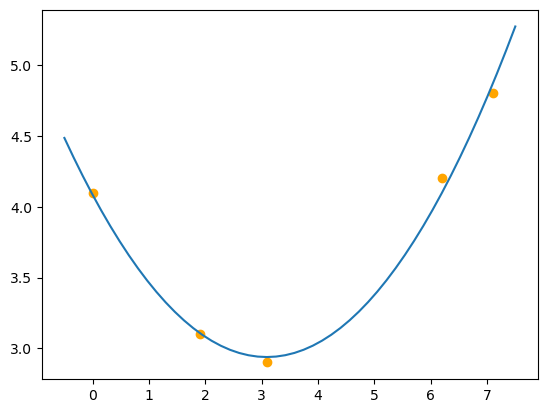

In [9]:
x = np.linspace(-0.5, 7.5)
y = xKoeffs[0] * x**2 + xKoeffs[1] * x + xKoeffs[2]

plt.plot(xcord, b, 'o', color="orange")
plt.plot(x, y)


## (b)

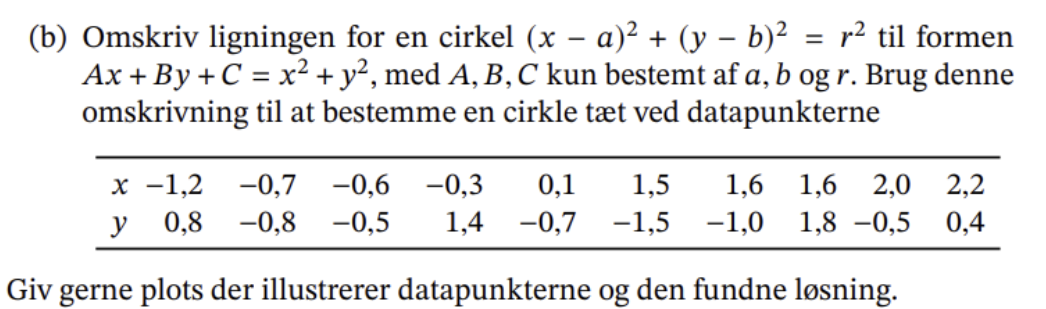

Først omskrives udtrykket:

$$(x-a)^2+(y-b)^2=r^2$$
$$\Updownarrow$$
$$x^2 + a^2 - 2ax + y^2 + b^2 - 2by = r^2$$
$$\Updownarrow$$
$$a^2 - 2ax + b^2 - 2by - r^2 = - x^2 - y^2$$
$$\Updownarrow$$
$$2ax + 2by - a^2 - b^2 + r^2 = x^2 + y^2 $$

Her er:

$$A = 2a$$
$$B = 2b$$
$$C = r^2 -a^2 - b^2$$

Nu bestemmes $A$, $B$ og $C$:

In [10]:
# Angivelse af datapunkter
x = np.array([-1.2, -0.7, -0.6, -0.3, 0.1, 1.5, 1.6, 1.6, 2.0, 2.2]) [:, np.newaxis]
y = np.array([0.8, -0.8, -0.5, 1.4, -0.7, -1.5, -1.0, 1.8, -0.5, 0.4])  [:, np.newaxis]

matrix = np.hstack([x, y, np.ones_like(x)])
matrix

array([[-1.2,  0.8,  1. ],
       [-0.7, -0.8,  1. ],
       [-0.6, -0.5,  1. ],
       [-0.3,  1.4,  1. ],
       [ 0.1, -0.7,  1. ],
       [ 1.5, -1.5,  1. ],
       [ 1.6, -1. ,  1. ],
       [ 1.6,  1.8,  1. ],
       [ 2. , -0.5,  1. ],
       [ 2.2,  0.4,  1. ]])

Jeg bruger igen denne opskrift:

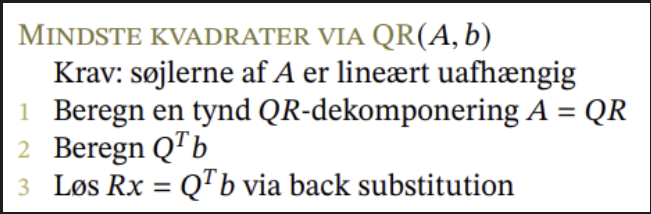

In [11]:
# 1.
Q, R = forbedret_gram_schmidt(matrix)

Q, R

(array([[-0.27824334,  0.2111536 ,  0.49797032],
        [-0.16230861, -0.26354805,  0.43673891],
        [-0.13912167, -0.16919864,  0.42531335],
        [-0.06956083,  0.41915565,  0.39236044],
        [ 0.02318694, -0.21095662,  0.34228983],
        [ 0.34780417, -0.41659501,  0.17571329],
        [ 0.37099112, -0.26118439,  0.16455248],
        [ 0.37099112,  0.59367252,  0.16825899],
        [ 0.4637389 , -0.09750096,  0.11792363],
        [ 0.51011279,  0.18278968,  0.09546965]]),
 array([[ 4.31277173, -0.38954067,  1.43759058],
        [ 0.        ,  3.27540197, -0.01221224],
        [ 0.        ,  0.        ,  2.81659088]]))

In [12]:
# 2.
b = x**2 + y**2

QTb = Q.T @ b
QTb

array([[8.58102453],
       [1.93034569],
       [6.09516063]])

In [13]:
koeffs = back_subs(R, QTb)
A, B, C = koeffs[:, 0]
A, B, C

(1.322297262468478, 0.5974146827101411, 2.164020578232152)

Jeg bruger nu beregningerne fra tidligere til at bestemme $a$, $b$ og $r$:

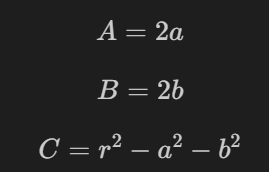

In [14]:
a = A/2
b = B/2
r = np.sqrt(C+a**2+b**2)

Jeg plotter nu punkterne og den cirkel som vi har beregnet:

(-1.3750690796154255,
 2.4764506719239363,
 -1.6719366921245573,
 2.1106705346157026)

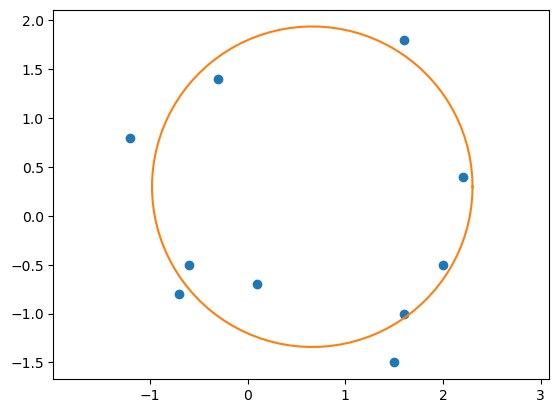

In [15]:
t = np.linspace(0, 2*np.pi, 100)
xc = r*np.cos(t)+a
yc = r*np.sin(t)+b

plt.plot(x, y, 'o')
plt.plot(xc, yc)
plt.axis('equal')

# Opgave 9.2

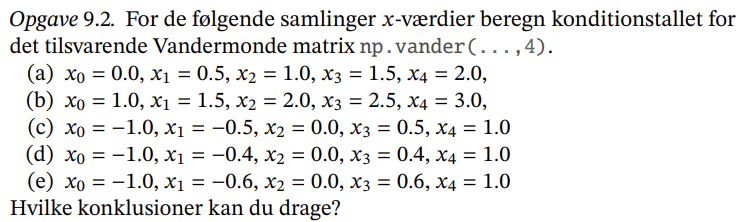

Vi ved fra notesættet at konditionstal for matricer er givet ved:

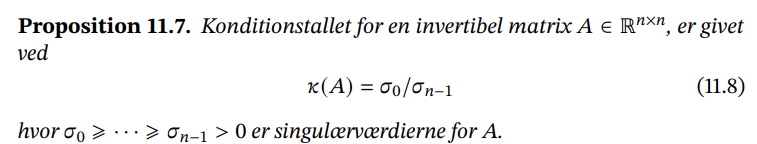

## (a)

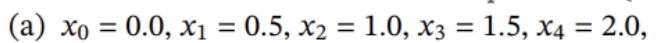

In [16]:
# Angivelse af data
x = np.array([0.0, 0.5, 1.0, 1.5, 2.0])

A = np.vander(x, 4)
A

array([[0.   , 0.   , 0.   , 1.   ],
       [0.125, 0.25 , 0.5  , 1.   ],
       [1.   , 1.   , 1.   , 1.   ],
       [3.375, 2.25 , 1.5  , 1.   ],
       [8.   , 4.   , 2.   , 1.   ]])

In [17]:
_, sigma, _ = np.linalg.svd(A)

kappaA = sigma[0]/sigma[-1]
kappaA

86.33187753066098

## (b)

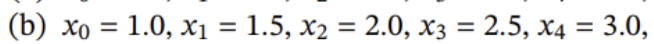

In [18]:
# Angivelse af data
x = np.array([1.0, 1.5, 2.0, 2.5, 3.0])

A = np.vander(x, 4)
A

array([[ 1.   ,  1.   ,  1.   ,  1.   ],
       [ 3.375,  2.25 ,  1.5  ,  1.   ],
       [ 8.   ,  4.   ,  2.   ,  1.   ],
       [15.625,  6.25 ,  2.5  ,  1.   ],
       [27.   ,  9.   ,  3.   ,  1.   ]])

In [19]:
_, sigma, _ = np.linalg.svd(A)

kappaA = sigma[0]/sigma[-1]
kappaA

1058.2220755143203

## (c)

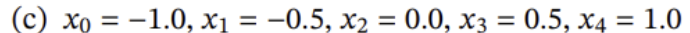

In [20]:
# Angivelse af data
x = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])

A = np.vander(x, 4)
A

array([[-1.   ,  1.   , -1.   ,  1.   ],
       [-0.125,  0.25 , -0.5  ,  1.   ],
       [ 0.   ,  0.   ,  0.   ,  1.   ],
       [ 0.125,  0.25 ,  0.5  ,  1.   ],
       [ 1.   ,  1.   ,  1.   ,  1.   ]])

In [21]:
_, sigma, _ = np.linalg.svd(A)

kappaA = sigma[0]/sigma[-1]
kappaA

7.103855898839079

## (d)

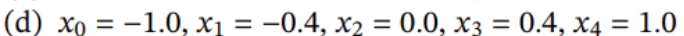

In [22]:
# Angivelse af data
x = np.array([-1.0, -0.4, 0.0, 0.4, 1.0])

A = np.vander(x, 4)
A

array([[-1.   ,  1.   , -1.   ,  1.   ],
       [-0.064,  0.16 , -0.4  ,  1.   ],
       [ 0.   ,  0.   ,  0.   ,  1.   ],
       [ 0.064,  0.16 ,  0.4  ,  1.   ],
       [ 1.   ,  1.   ,  1.   ,  1.   ]])

In [23]:
_, sigma, _ = np.linalg.svd(A)

kappaA = sigma[0]/sigma[-1]
kappaA

7.658393083687569

## (e)



In [24]:
# Angivelse af data
x = np.array([-1.0, -0.6, 0.0, 0.6, 1.0])

A = np.vander(x, 4)
A

array([[-1.   ,  1.   , -1.   ,  1.   ],
       [-0.216,  0.36 , -0.6  ,  1.   ],
       [ 0.   ,  0.   ,  0.   ,  1.   ],
       [ 0.216,  0.36 ,  0.6  ,  1.   ],
       [ 1.   ,  1.   ,  1.   ,  1.   ]])

In [25]:
_, sigma, _ = np.linalg.svd(A)

kappaA = sigma[0]/sigma[-1]
kappaA

7.283574631314216

På baggrund af disse observationer kan jeg se at vi får det mindste konditionstal når vores x-værdier er lineært fordelt ligeligt omkring origo.

# Opgave 9.3

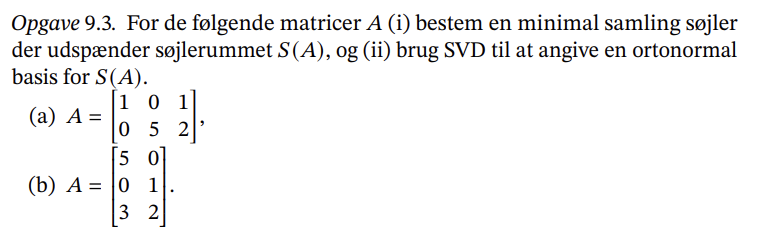

## (a)

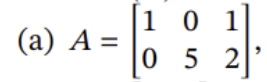

Der skal bruges $2$ søjler til at afspejle søjlerummet af $A$:

I dette tilfælde er samlingen blot de to første søjler.

Generelt udgør $U$ i en svd en ortonormal basis for søjlerummet af $A$:

In [26]:
A = np.array([[1, 0, 1],
              [0, 5, 2]], dtype=float)

U, _, _ = np.linalg.svd(A, full_matrices=False)

U

array([[ 0.07347291, -0.99729721],
       [ 0.99729721,  0.07347291]])

## (b)

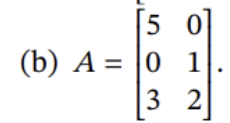

I dette tilfælde er de to søjler lineært uafhænige, og dermed udgør de to hele søjle rummet. Altså er den mininmale samling af søjler som udgør $S(A)$ de to første søjler.

In [27]:
A = np.array([[5, 0],
              [0, 1],
              [3, 2]], dtype=float)

U, _, _ = np.linalg.svd(A, full_matrices=False)

U

array([[-0.8266759 ,  0.49944247],
       [-0.03285637, -0.50264481],
       [-0.56171827, -0.70562413]])

# Opgave 9.4

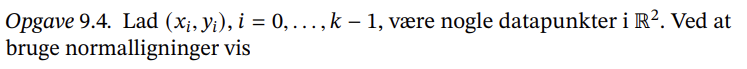

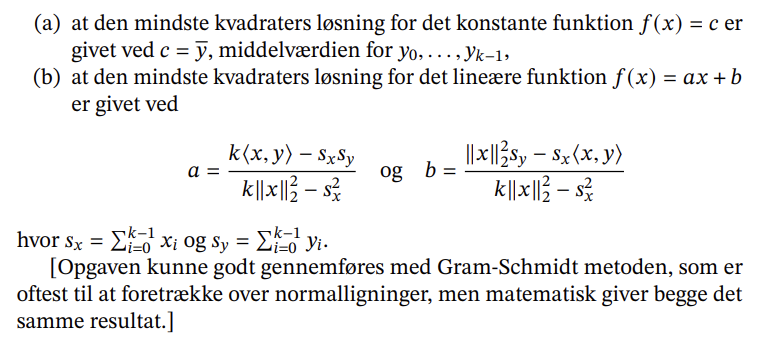

## (a)

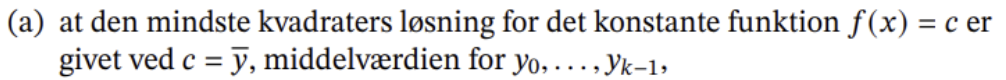

Vi opstiller ligningssystemet på følgende måde:

$$Ax = Pb = UU^Tb$$
$$\Updownarrow$$
$$\begin{bmatrix} 1 \\ 1 \\ \vdots \\ 1 \end{bmatrix} \begin{bmatrix} c \end{bmatrix} = P\begin{bmatrix} y_0 \\ y_1 \\ \vdots \\ y_{k-1} \end{bmatrix}$$

Dette system kan løses vha normalligninger ved at beregne pseudo-inversen: $x = A^+ Pb$

$$A^+ = V \Sigma^{-1} U^T$$

Vi ved at $Pb = proj_{S(A)}(b) = \frac{\langle b, A \rangle}{\langle A, A \rangle} * A = \frac{b}{k} * A = \sum_{<b>} \frac{b_i}{k}$, hvor $k$ er mængden af elementer i A

Dette er netop gennemsnittet af elementerne i $b$ (vores $y$-koordinater).

## (b)

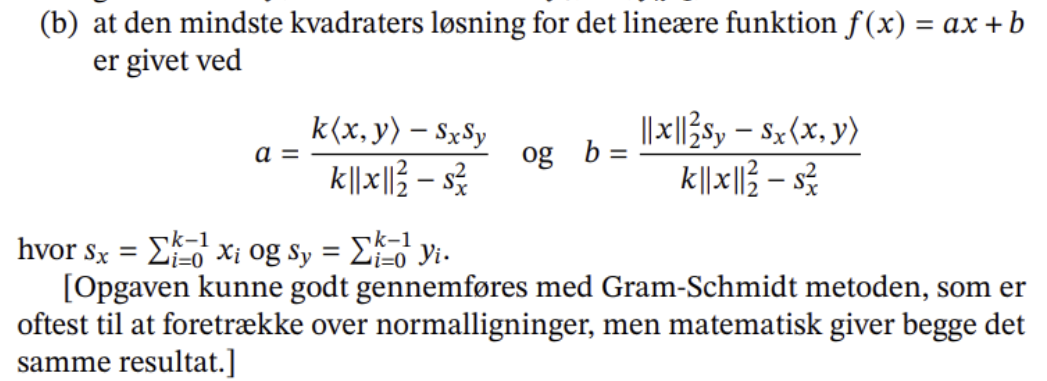

Vi opstiller ligningssystemet på følgende måde:

Ved at gange $VAT$ på venstre side, på begge sider af lighedstegnet, så kan vi komprimere systemet ned til en system med $A^t y$ i søjlerummet af: $A$:

$$A^TAx = A^Ty = b$$
$$\Updownarrow$$
$$\begin{bmatrix} x_0 & x_1 & \dots & x_{k-1} \\ 1 & 1 & \dots & 1 \end{bmatrix} \begin{bmatrix} x_0 & 1 \\ x_1 & 1 \\ \vdots \\ x_{k-1} & 1 \end{bmatrix} \begin{bmatrix} a \\ b \end{bmatrix} = \begin{bmatrix} x_0 & x_1 & \dots & x_{k-1} \\ 1 & 1 & \dots & 1 \end{bmatrix} \begin{bmatrix} y_0 \\ y_1 \\ \vdots \\ y_{k-1} \end{bmatrix}$$
$$||$$
$$\begin{bmatrix} ||x||_2^2 & s_x \\ s_x & k \end{bmatrix} \begin{bmatrix} a \\ b \end{bmatrix} = \begin{bmatrix} \langle x, y \rangle \\ s_y \end{bmatrix}$$

Vi har nu en kvadratisk matrice, og oven i det, så er den også i $R^{2x2}$, hvilket vil sige at vi kan bruge den formel som vi kender:

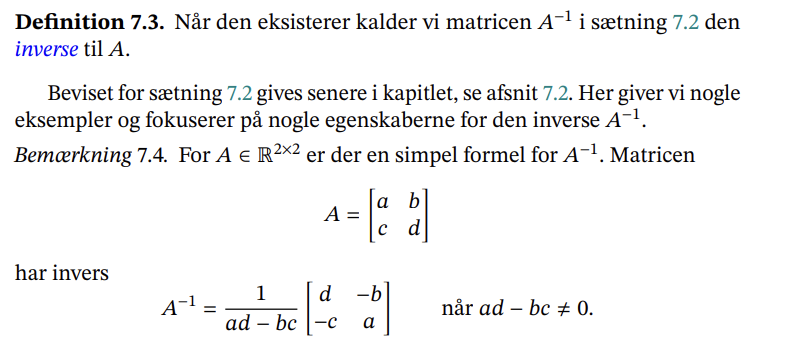

$$||$$
$$\begin{bmatrix} a \\ b \end{bmatrix} = \frac{1}{k||x||_2^2 - s_x^2} \begin{bmatrix} k & -s_x \\ -s_x & ||x||_2^2 \end{bmatrix}  \begin{bmatrix} \langle x, y \rangle \\ s_y \end{bmatrix}$$

$$||$$
$$\begin{bmatrix} a \\ b \end{bmatrix} = \frac{1}{k||x||_2^2 - s_x^2} \begin{bmatrix} k \langle x,y \rangle - s_x s_y \\ -s_x \langle x,y \rangle + s_y ||x||_2^2 \end{bmatrix}$$

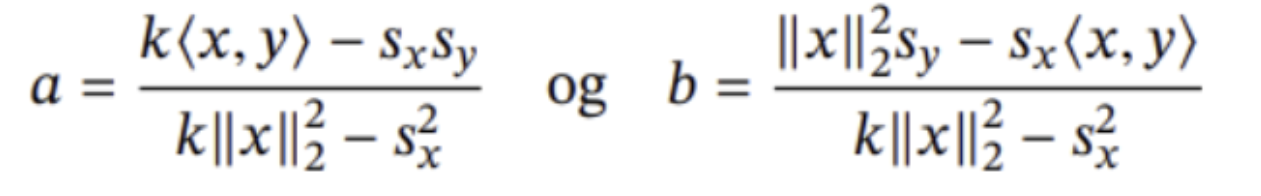

Herfra er det ret tydeligt at $a$ og $b$ er givet af de som opgaven siger.

# Opgave 9.5

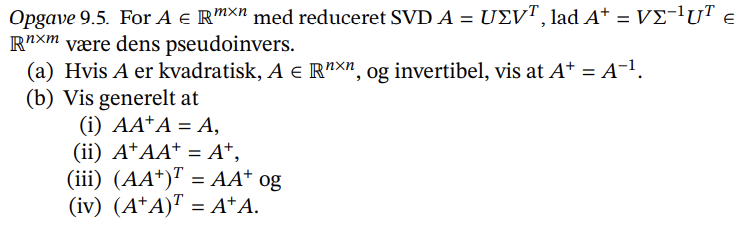

## (a)

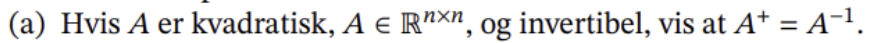

Dette kan lynhurtigt ses således:

$$A^{-1} = (U \Sigma V^T)^{-1} = (V^T)^{-1} \Sigma^{-1} U^{-1} = V \Sigma^{-1} U^T = A^+$$

## (b)

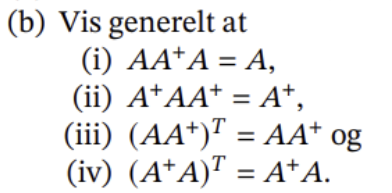

Vi ved at $U$ og $V$ er ortogonale matricer, ikke kvadratiske, og dermed er $U U^T \neq U^T U = I_n$, og det samme gælder v

### (i)

$$A A^+ A = U \Sigma V^T V \Sigma^{-1} U^T U \Sigma V^T = U \Sigma I_n \Sigma^{-1} U^T U \Sigma V^T = U U^T U \Sigma V^T = U I_n \Sigma V^T = U \Sigma V^T = A$$

### (ii)

$$A^+AA^+ = V \Sigma^{-1} U^T U \Sigma V^T V \Sigma^{-1} U^T = V I_n V^T V \Sigma^{-1} U^T  = V \Sigma^{-1} U^T = A^+$$

### (iii)

Her vender vi blot rundt på rækkefølgen og transponerer.

$$(A A^+)^T = (U \Sigma V^T V \Sigma^{-1} U^T)^T = U \Sigma V^T V \Sigma^{-1} U^T = A A^+$$

### (iv)

Dette gælder selvfølgelig også, som følge af (iii)